# Seminar Notebook: VQ-VAE, Autoregressive Priors, and a Gumbel-Softmax Variant

**Topic:** Vector-Quantized Variational Autoencoders (VQ-VAE) and related discrete latent bottlenecks  
**Audience:** upper-undergraduate / graduate students in machine learning  
**Recommended duration:** 80–95 minutes

This notebook is designed as a **teaching notebook with runnable defaults**. Every training cell below runs out of the box on the small `sklearn` digits dataset, so the seminar demo works offline and on CPU.

It covers:
- hard vector quantization and straight-through training,
- default end-to-end training of a small VQ-VAE,
- autoregressive prior learning over discrete code grids,
- sampling by decoding prior-generated code sequences,
- a second part that replaces hard nearest-neighbor quantization with a **Gumbel-Softmax** relaxation.

**Primary references**
1. Aaron van den Oord, Oriol Vinyals, Koray Kavukcuoglu. *Neural Discrete Representation Learning*. NeurIPS 2017. (`arXiv:1711.00937`)
2. Ali Razavi, Aaron van den Oord, Oriol Vinyals. *Generating Diverse High-Fidelity Images with VQ-VAE-2*. NeurIPS 2019. (`arXiv:1906.00446`)
3. Eric Jang, Shixiang Gu, Ben Poole. *Categorical Reparameterization with Gumbel-Softmax*. ICLR 2017. (`arXiv:1611.01144`)
4. Chris J. Maddison, Andriy Mnih, Yee Whye Teh. *The Concrete Distribution: A Continuous Relaxation of Discrete Random Variables*. ICLR 2017. (`arXiv:1611.00712`)


## Suggested seminar flow

| Time | Section | Goal |
|---|---|---|
| 0–10 min | Motivation and background | Why discrete latents matter |
| 10–25 min | Core VQ-VAE idea | Codebook, nearest-neighbor lookup, loss terms |
| 25–40 min | Implementation | Walk through the PyTorch modules |
| 40–50 min | Default training run | Train a small tokenizer live |
| 50–65 min | Prior learning and sampling | Learn an autoregressive model over code indices |
| 65–80 min | Gumbel-Softmax variant | Compare hard quantization vs relaxed categorical latents |
| 80–95 min | Discussion | VQ-VAE-2, failure modes, questions, exercises |

**Teaching cue:** open with  
> "Why might a model prefer a short grid of discrete tokens over one big continuous latent vector?"


## Learning objectives

By the end of the seminar, students should be able to:

1. explain why VQ-VAE uses a **discrete codebook**;
2. write the **nearest-neighbor quantization rule** and the **three-part VQ-VAE loss**;
3. explain the role of the **straight-through estimator**;
4. train a minimal **VQ-VAE tokenizer** end to end;
5. fit a simple **autoregressive prior** on the learned latent indices and sample from it;
6. compare original **VQ-VAE** with a **Gumbel-Softmax** discrete-latent alternative.

## TL;DR

A VQ-VAE takes an input $x$, maps it to a continuous encoder output $z_e(x)$, replaces each latent vector by the **nearest codebook entry**, and decodes the quantized tensor to reconstruct the input.  
The training objective combines:
- a **reconstruction term**,
- a **codebook term** that moves embeddings toward encoder outputs,
- and a **commitment term** that keeps encoder outputs close to the chosen codes.

After the tokenizer is learned, we can fit a **separate autoregressive prior** over the discrete code indices and generate new samples by decoding prior-generated code grids.

In the second half of the notebook, we replace the hard nearest-neighbor step with a **Gumbel-Softmax relaxation** to show a related way to train discrete latent variables with differentiable sampling.


## 1. Background: from AE and VAE to VQ-VAE

A standard autoencoder learns:
- an encoder $E(x)$,
- a decoder $D(z)$,
- and a reconstruction objective such as MSE or cross-entropy.

A standard VAE adds a probabilistic latent-variable model:
- $q_\phi(z \mid x)$ as an approximate posterior,
- $p_\theta(x \mid z)$ as a decoder,
- and an ELBO objective with a KL regularizer.

### Why is VQ-VAE interesting?

Continuous VAEs can suffer from **posterior collapse**, especially when the decoder is strong.  
VQ-VAE replaces continuous latent sampling with a **discrete bottleneck** based on nearest-neighbor lookup in a learned codebook.

**Teaching cue:** emphasize that VQ-VAE quantizes the **latent representation**, not the model weights.


## 2. Intuition: vector quantization in 2D

Imagine the encoder outputs points in a continuous space.  
A learned codebook stores prototype vectors:
$$
e_1, e_2, \dots, e_K \in \mathbb{R}^D.
$$

Quantization means: for each encoder output, choose the **nearest** prototype and replace the original vector by that prototype.

This turns a continuous representation into:
- a **discrete index**,
- plus a shared **lookup table** of embeddings.


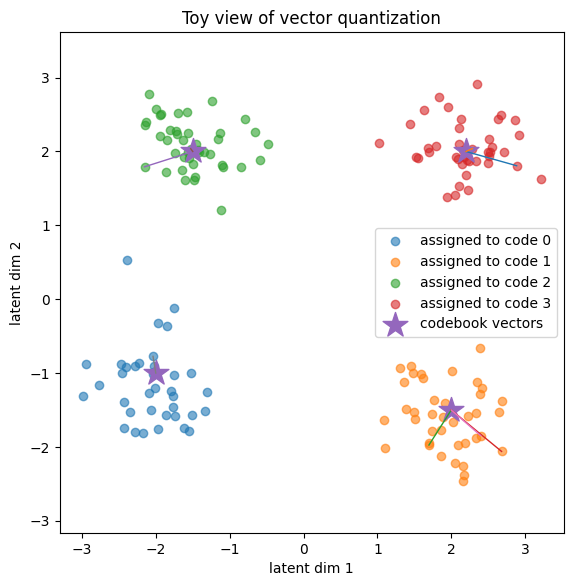

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

codebook = np.array([
    [-2.0, -1.0],
    [ 2.0, -1.5],
    [-1.5,  2.0],
    [ 2.2,  2.0],
], dtype=float)

cluster_ids = rng.integers(0, len(codebook), size=160)
z_e = codebook[cluster_ids] + 0.45 * rng.standard_normal((160, 2))

distances = ((z_e[:, None, :] - codebook[None, :, :]) ** 2).sum(axis=-1)
assignments = distances.argmin(axis=1)
z_q = codebook[assignments]

plt.figure(figsize=(6.5, 6.5))
for k in range(len(codebook)):
    pts = z_e[assignments == k]
    plt.scatter(pts[:, 0], pts[:, 1], alpha=0.6, label=f"assigned to code {k}")
plt.scatter(codebook[:, 0], codebook[:, 1], marker="*", s=350, label="codebook vectors")

for i in range(0, len(z_e), 20):
    plt.plot([z_e[i, 0], z_q[i, 0]], [z_e[i, 1], z_q[i, 1]], linewidth=1)

plt.title("Toy view of vector quantization")
plt.xlabel("latent dim 1")
plt.ylabel("latent dim 2")
plt.legend()
plt.axis("equal")
plt.show()


### What to say when showing the plot

- The **clouds of points** represent encoder outputs.
- The **stars** are learned codebook vectors.
- Each point is replaced by the nearest codebook vector.
- The model therefore sends a **discrete code index** to the decoder.

This is the central move in VQ-VAE:
continuous encoder features $\rightarrow$ discrete latent tokens.


## 3. Core VQ-VAE equations

The model is:

$$
x \xrightarrow{E} z_e(x) \xrightarrow{\text{nearest codebook lookup}} z_q(x) \xrightarrow{D} \hat{x}
$$

with codebook
$$
\mathcal{E} = \{e_1, e_2, \dots, e_K\}, \qquad e_k \in \mathbb{R}^D.
$$

For each latent location, choose
$$
k = \arg\min_j \lVert z_e(x) - e_j \rVert_2
\qquad \text{and} \qquad
z_q(x) = e_k.
$$

A standard implementation-friendly loss is:

$$
\mathcal{L}
=
\underbrace{\mathcal{L}_{\text{recon}}(x, \hat{x})}_{\text{reconstruction}}
+
\underbrace{\lVert \mathrm{sg}[z_e(x)] - e \rVert_2^2}_{\text{codebook}}
+
\beta
\underbrace{\lVert z_e(x) - \mathrm{sg}[e] \rVert_2^2}_{\text{commitment}}.
$$

Here $\mathrm{sg}[\cdot]$ means **stop-gradient**.

**Teaching cue:** students often understand the model faster once the terms are mapped to  
"reconstruct", "move the codebook", and "make the encoder commit".


## 4. Straight-through gradients and why the prior is learned later

Nearest-neighbor lookup uses `argmin`, so it is not differentiable in the usual way.  
VQ-VAE uses the **straight-through estimator**:

```python
z_q_st = z_e + (z_q - z_e).detach()
```

This gives:
- forward value = `z_q`,
- backward gradient w.r.t. `z_e` = identity.

### Where is the KL term during tokenizer training?

In the original VQ-VAE setup, the prior over discrete latents is treated as uniform during tokenizer training, so the KL contribution is **constant** with respect to the encoder.  
That is why VQ-VAE is usually trained in **two stages**:

1. learn the tokenizer (encoder, codebook, decoder);
2. fit a separate prior over the discrete latent indices.

In the original papers the prior is autoregressive in latent space.  
In this notebook we use a **small GRU over a flattened latent grid** because it is short, easy to teach, and still shows the same factorization idea.


## 5. Setup: runnable defaults for a seminar demo

The defaults below are tuned for:
- **offline execution**,
- a **CPU-friendly** live demo,
- and a quick path from tokenizer training to prior learning and sampling.

The dataset is the small `sklearn` digits dataset, upsampled from `8x8` to `16x16`.  
That keeps training fast while still giving a `4x4` latent grid after two stride-2 downsampling layers.


In [2]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import math
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_digits
from torch.utils.data import DataLoader, TensorDataset, random_split

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

plt.rcParams["figure.dpi"] = 120

def set_seed(seed: int = 7) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)
DEVICE = torch.device("mps")

CFG = {
    "seed": 7,
    "image_size": 16,
    "batch_size": 128,
    "hidden_channels": 64,
    "embedding_dim": 32,
    "num_embeddings": 64,
    "commitment_cost": 0.25,
    "vq_lr": 2e-3,
    "vq_epochs": 6,
    "prior_lr": 2e-3,
    "prior_epochs": 10,
    "prior_hidden_dim": 128,
    "prior_token_dim": 64,
    "sample_temperature": 0.95,
    "gumbel_lr": 2e-3,
    "gumbel_epochs": 8,
    "gumbel_tau_start": 1.4,
    "gumbel_tau_end": 0.5,
    "gumbel_kl_weight": 5e-4,
}

{"device": str(DEVICE), **CFG}


{'device': 'mps',
 'seed': 7,
 'image_size': 16,
 'batch_size': 128,
 'hidden_channels': 64,
 'embedding_dim': 32,
 'num_embeddings': 64,
 'commitment_cost': 0.25,
 'vq_lr': 0.002,
 'vq_epochs': 6,
 'prior_lr': 0.002,
 'prior_epochs': 10,
 'prior_hidden_dim': 128,
 'prior_token_dim': 64,
 'sample_temperature': 0.95,
 'gumbel_lr': 0.002,
 'gumbel_epochs': 8,
 'gumbel_tau_start': 1.4,
 'gumbel_tau_end': 0.5,
 'gumbel_kl_weight': 0.0005}

In [3]:
def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def prepare_digits_dataloaders(
    image_size: int = 16,
    batch_size: int = 128,
    val_fraction: float = 0.15,
) -> Tuple[DataLoader, DataLoader]:
    digits = load_digits()

    x = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
    if image_size != 8:
        x = F.interpolate(x, size=(image_size, image_size), mode="bilinear", align_corners=False)

    y = torch.tensor(digits.target, dtype=torch.long)

    dataset = TensorDataset(x, y)
    n_val = int(len(dataset) * val_fraction)
    n_train = len(dataset) - n_val

    train_dataset, val_dataset = random_split(
        dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(CFG["seed"]),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
    return train_loader, val_loader

def show_batch(x: torch.Tensor, title: str, n: int = 8) -> None:
    x = x[:n].detach().cpu()
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2.0))
    for ax, image in zip(axes, x):
        ax.imshow(image.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_reconstructions(original: torch.Tensor, recon: torch.Tensor, title: str, n: int = 8) -> None:
    original = original[:n].detach().cpu()
    recon = recon[:n].detach().cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(original[i].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("original", rotation=90, labelpad=12)
    axes[1, 0].set_ylabel("recon", rotation=90, labelpad=18)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_image_grid(images: torch.Tensor, title: str, ncols: int = 4) -> None:
    images = images.detach().cpu()
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.8 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis("off")

    for ax, image in zip(axes.flat, images):
        ax.imshow(image.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_history_pair(
    history: List[Dict[str, float]],
    train_key: str,
    val_key: str,
    title: str,
    ylabel: str,
    train_label: str = "train",
    val_label: str = "val",
) -> None:
    epochs = [row["epoch"] for row in history]
    train_values = [row[train_key] for row in history]
    val_values = [row[val_key] for row in history]

    plt.figure(figsize=(6.2, 4.0))
    plt.plot(epochs, train_values, marker="o", label=train_label)
    plt.plot(epochs, val_values, marker="o", label=val_label)
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def code_usage_histogram(indices: torch.Tensor, num_embeddings: int, title: str) -> None:
    flat = indices.detach().cpu().view(-1).numpy()
    counts = np.bincount(flat, minlength=num_embeddings)

    plt.figure(figsize=(7.0, 3.2))
    plt.bar(np.arange(num_embeddings), counts)
    plt.xlabel("code index")
    plt.ylabel("count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


train examples: 1528
val examples:   269
batch shape:    (128, 1, 16, 16)
value range:    [0.000, 1.000]


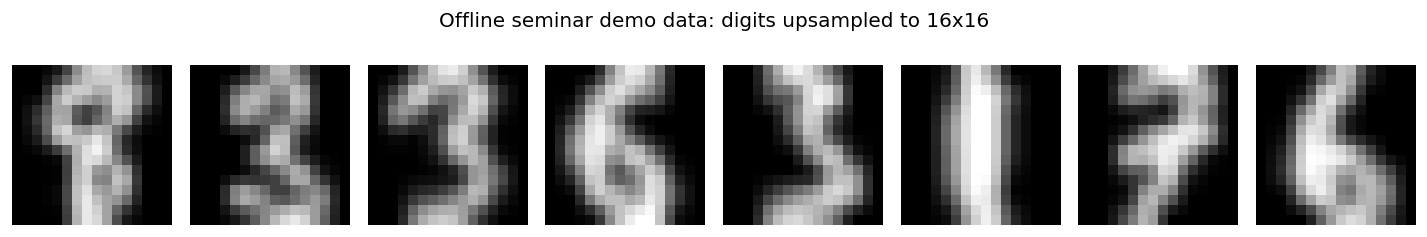

In [4]:
train_loader, val_loader = prepare_digits_dataloaders(
    image_size=CFG["image_size"],
    batch_size=CFG["batch_size"],
)

x_demo, y_demo = next(iter(train_loader))
print(f"train examples: {len(train_loader.dataset)}")
print(f"val examples:   {len(val_loader.dataset)}")
print(f"batch shape:    {tuple(x_demo.shape)}")
print(f"value range:    [{x_demo.min().item():.3f}, {x_demo.max().item():.3f}]")

show_batch(x_demo, title="Offline seminar demo data: digits upsampled to 16x16")


## 6. Minimal VQ-VAE implementation

The implementation below keeps the ideas explicit:

- `Encoder` maps images to a spatial latent map.
- `VectorQuantizer` finds the nearest code for each latent location.
- `Decoder` reconstructs from the quantized embeddings.
- `VQVAE` ties the parts together and exposes helper methods for:
  - encoding images to discrete indices,
  - decoding discrete indices back to images.

Because the default input size is `16x16`, the encoder produces a `4x4` grid of discrete codes.


In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(inplace=False),
            nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(channels, channels, kernel_size=1, stride=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, embedding_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels // 2, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.ReLU(inplace=False),
            nn.Conv2d(hidden_channels // 2, hidden_channels, kernel_size=4, stride=2, padding=1),  # 8 -> 4
            nn.ReLU(inplace=False),
            ResidualBlock(hidden_channels),
            ResidualBlock(hidden_channels),
            nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, embedding_dim: int, hidden_channels: int, out_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, kernel_size=3, stride=1, padding=1),
            ResidualBlock(hidden_channels),
            ResidualBlock(hidden_channels),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(hidden_channels, hidden_channels // 2, kernel_size=4, stride=2, padding=1),  # 4 -> 8
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(hidden_channels // 2, out_channels, kernel_size=4, stride=2, padding=1),  # 8 -> 16
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class VectorQuantizer(nn.Module):
    def __init__(
        self,
        num_embeddings: int,
        embedding_dim: int,
        commitment_cost: float = 0.25,
    ):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1.0 / num_embeddings, 1.0 / num_embeddings)

    def forward(self, z_e: torch.Tensor):
        if z_e.ndim != 4:
            raise ValueError(f"Expected BCHW tensor, got shape {tuple(z_e.shape)}")
        if z_e.size(1) != self.embedding_dim:
            raise ValueError(
                f"Expected channel dimension {self.embedding_dim}, got {z_e.size(1)}"
            )

        b, c, h, w = z_e.shape
        z = z_e.permute(0, 2, 3, 1).contiguous()         # [B, H, W, C]
        flat_z = z.view(-1, c)                            # [B*H*W, C]
        codebook = self.embedding.weight                  # [K, C]

        distances = (
            flat_z.pow(2).sum(dim=1, keepdim=True)
            + codebook.pow(2).sum(dim=1)
            - 2 * flat_z @ codebook.t()
        )

        encoding_indices = torch.argmin(distances, dim=1)             # [B*H*W]
        z_q = self.embedding(encoding_indices).view(b, h, w, c)       # [B, H, W, C]

        codebook_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        z_q_st = z + (z_q - z).detach()

        encodings = F.one_hot(encoding_indices, self.num_embeddings).type(flat_z.dtype)
        avg_probs = encodings.mean(dim=0)
        perplexity = torch.exp(-(avg_probs * torch.log(avg_probs + 1e-10)).sum())

        z_q_st = z_q_st.permute(0, 3, 1, 2).contiguous()
        encoding_indices = encoding_indices.view(b, h, w)

        stats = {
            "vq_loss": vq_loss,
            "codebook_loss": codebook_loss,
            "commitment_loss": commitment_loss,
            "perplexity": perplexity,
            "encoding_indices": encoding_indices,
        }
        return z_q_st, stats


class VQVAE(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        hidden_channels: int = 64,
        embedding_dim: int = 32,
        num_embeddings: int = 64,
        commitment_cost: float = 0.25,
    ):
        super().__init__()
        self.encoder = Encoder(in_channels, hidden_channels, embedding_dim)
        self.vq = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=embedding_dim,
            commitment_cost=commitment_cost,
        )
        self.decoder = Decoder(embedding_dim, hidden_channels, in_channels)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def quantize(self, z_e: torch.Tensor):
        return self.vq(z_e)

    def decode(self, z_q: torch.Tensor) -> torch.Tensor:
        return self.decoder(z_q)

    def forward(self, x: torch.Tensor):
        z_e = self.encode(x)
        z_q, stats = self.quantize(z_e)
        x_recon = self.decode(z_q)
        return x_recon, stats

    def compute_loss(self, x: torch.Tensor, x_recon: torch.Tensor, stats: Dict[str, torch.Tensor]):
        recon_loss = F.mse_loss(x_recon, x)
        total_loss = recon_loss + stats["vq_loss"]
        return {
            "loss": total_loss,
            "recon_loss": recon_loss,
            **stats,
        }

    @torch.no_grad()
    def encode_to_indices(self, x: torch.Tensor) -> torch.Tensor:
        z_e = self.encode(x)
        _, stats = self.quantize(z_e)
        return stats["encoding_indices"]

    @torch.no_grad()
    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        z_q = self.vq.embedding(indices).permute(0, 3, 1, 2).contiguous()
        return self.decode(z_q)


In [6]:
vqvae_dry = VQVAE(
    in_channels=1,
    hidden_channels=CFG["hidden_channels"],
    embedding_dim=CFG["embedding_dim"],
    num_embeddings=CFG["num_embeddings"],
    commitment_cost=CFG["commitment_cost"],
).to(DEVICE)

x = torch.rand(4, 1, CFG["image_size"], CFG["image_size"], device=DEVICE)
x_recon, stats = vqvae_dry(x)
losses = vqvae_dry.compute_loss(x, x_recon, stats)

summary = {
    "input_shape": tuple(x.shape),
    "reconstruction_shape": tuple(x_recon.shape),
    "latent_index_shape": tuple(stats["encoding_indices"].shape),
    "trainable_parameters": count_parameters(vqvae_dry),
    "recon_loss": float(losses["recon_loss"].detach().cpu()),
    "vq_loss": float(losses["vq_loss"].detach().cpu()),
    "perplexity": float(losses["perplexity"].detach().cpu()),
}
summary


{'input_shape': (4, 1, 16, 16),
 'reconstruction_shape': (4, 1, 16, 16),
 'latent_index_shape': (4, 4, 4),
 'trainable_parameters': 253665,
 'recon_loss': 0.08705997467041016,
 'vq_loss': 0.010311666876077652,
 'perplexity': 2.9644525051116943}

## 7. Train the tokenizer by default

The next two cells are **not templates**.  
They run as-is and train a compact VQ-VAE on the digits demo dataset.

That makes the seminar flow simple:

1. run the cell,
2. watch the reconstruction loss and perplexity,
3. immediately reuse the learned code indices for prior learning.

For stronger results outside a live seminar, raise the epoch counts and swap in a larger dataset such as MNIST, Fashion-MNIST, CIFAR-10, or image patches.


In [7]:
def evaluate_vqvae(model: VQVAE, loader: DataLoader, device: torch.device) -> Dict[str, float]:
    model.eval()
    totals = {"loss": 0.0, "recon_loss": 0.0, "perplexity": 0.0}
    n_examples = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_recon, stats = model(x)
            losses = model.compute_loss(x, x_recon, stats)

            batch_size = x.size(0)
            totals["loss"] += losses["loss"].item() * batch_size
            totals["recon_loss"] += losses["recon_loss"].item() * batch_size
            totals["perplexity"] += losses["perplexity"].item() * batch_size
            n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}

def train_vqvae(
    model: VQVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    device: torch.device,
) -> List[Dict[str, float]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        totals = {"loss": 0.0, "recon_loss": 0.0, "perplexity": 0.0}
        n_examples = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad(set_to_none=True)
            x_recon, stats = model(x)
            losses = model.compute_loss(x, x_recon, stats)
            losses["loss"].backward()
            optimizer.step()

            batch_size = x.size(0)
            totals["loss"] += losses["loss"].item() * batch_size
            totals["recon_loss"] += losses["recon_loss"].item() * batch_size
            totals["perplexity"] += losses["perplexity"].item() * batch_size
            n_examples += batch_size

        train_metrics = {key: value / n_examples for key, value in totals.items()}
        val_metrics = evaluate_vqvae(model, val_loader, device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_recon_loss": train_metrics["recon_loss"],
            "train_perplexity": train_metrics["perplexity"],
            "val_loss": val_metrics["loss"],
            "val_recon_loss": val_metrics["recon_loss"],
            "val_perplexity": val_metrics["perplexity"],
        }
        history.append(row)

        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"train loss={row['train_loss']:.4f} | "
            f"val loss={row['val_loss']:.4f} | "
            f"val recon={row['val_recon_loss']:.4f} | "
            f"val perplexity={row['val_perplexity']:.2f}"
        )

    return history


In [8]:
set_seed(CFG["seed"])

vqvae_model = VQVAE(
    in_channels=1,
    hidden_channels=CFG["hidden_channels"],
    embedding_dim=CFG["embedding_dim"],
    num_embeddings=CFG["num_embeddings"],
    commitment_cost=CFG["commitment_cost"],
).to(DEVICE)

vq_history = train_vqvae(
    model=vqvae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG["vq_epochs"],
    lr=CFG["vq_lr"],
    device=DEVICE,
)

{
    "final_val_loss": round(vq_history[-1]["val_loss"], 4),
    "final_val_recon_loss": round(vq_history[-1]["val_recon_loss"], 4),
    "final_val_perplexity": round(vq_history[-1]["val_perplexity"], 2),
    "trainable_parameters": count_parameters(vqvae_model),
}


epoch 01/6 | train loss=0.1474 | val loss=0.1274 | val recon=0.1198 | val perplexity=4.87
epoch 02/6 | train loss=0.7299 | val loss=0.6846 | val recon=0.0546 | val perplexity=3.37
epoch 03/6 | train loss=0.2008 | val loss=0.0611 | val recon=0.0479 | val perplexity=4.35
epoch 04/6 | train loss=0.0542 | val loss=0.0472 | val recon=0.0428 | val perplexity=4.15
epoch 05/6 | train loss=0.0434 | val loss=0.0406 | val recon=0.0360 | val perplexity=4.64
epoch 06/6 | train loss=0.0387 | val loss=0.0375 | val recon=0.0278 | val perplexity=4.89


{'final_val_loss': 0.0375,
 'final_val_recon_loss': 0.0278,
 'final_val_perplexity': 4.89,
 'trainable_parameters': 253665}

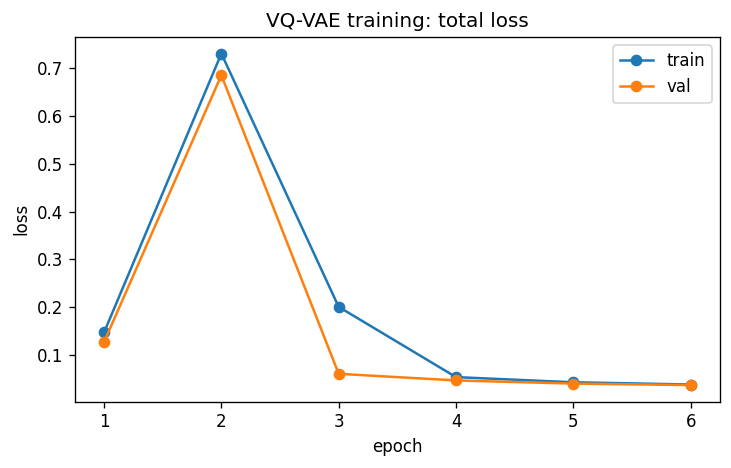

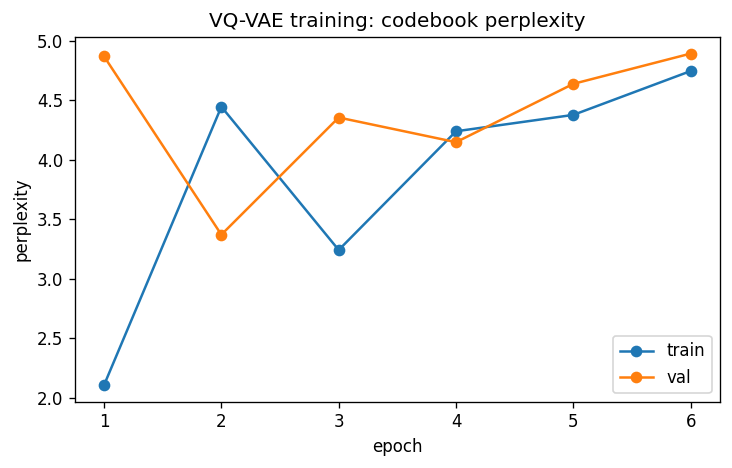

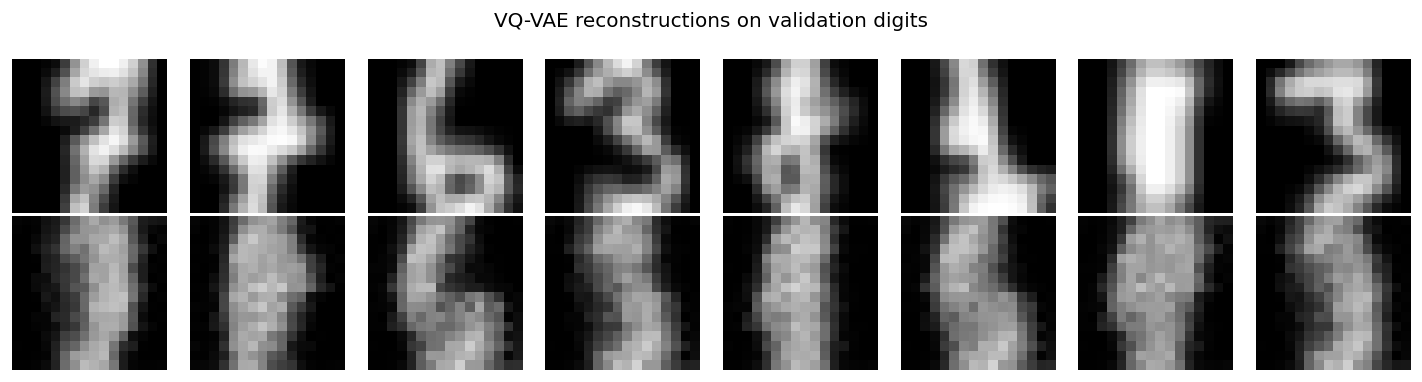

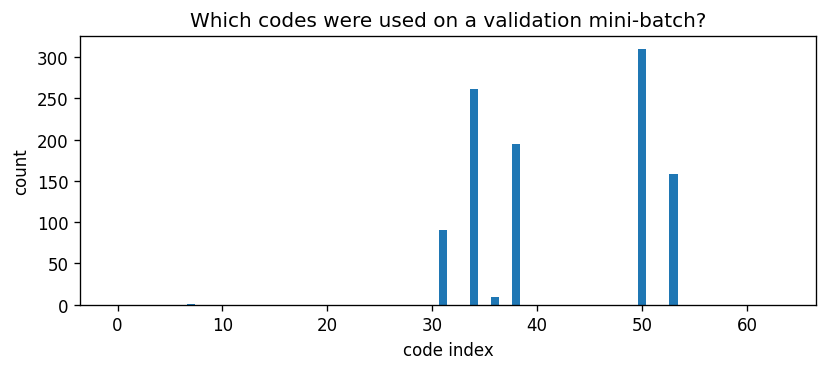

In [9]:
plot_history_pair(
    vq_history,
    train_key="train_loss",
    val_key="val_loss",
    title="VQ-VAE training: total loss",
    ylabel="loss",
)

plot_history_pair(
    vq_history,
    train_key="train_perplexity",
    val_key="val_perplexity",
    title="VQ-VAE training: codebook perplexity",
    ylabel="perplexity",
)

x_val, _ = next(iter(val_loader))
x_val = x_val.to(DEVICE)

with torch.no_grad():
    x_recon, val_stats = vqvae_model(x_val[:8])

show_reconstructions(
    x_val[:8],
    x_recon[:8],
    title="VQ-VAE reconstructions on validation digits",
    n=8,
)

with torch.no_grad():
    val_indices = vqvae_model.encode_to_indices(x_val[:64])

code_usage_histogram(
    val_indices,
    num_embeddings=CFG["num_embeddings"],
    title="Which codes were used on a validation mini-batch?",
)


## 8. Learn an autoregressive prior over the latent code grid

Once the tokenizer is trained, each image maps to a small grid of integers.  
If we flatten that grid in row-major order, we can factorize the prior as

$$
p(z_1, z_2, \dots, z_T) = \prod_{t=1}^{T} p(z_t \mid z_{<t}).
$$

A 2D PixelCNN-style prior is the canonical story in the original VQ-VAE line of work, but for a seminar notebook a tiny **GRU prior** is easier to explain and runs very fast.

### Seminar framing

- **Tokenizer stage:** learn a compressed discrete alphabet.
- **Prior stage:** learn how likely token sequences are.
- **Sampling:** draw a token sequence from the prior, reshape to a grid, decode with the trained decoder.


In [10]:
class LatentGRUPrior(nn.Module):
    def __init__(self, num_embeddings: int, hidden_dim: int = 128, token_dim: int = 64):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.start_token = num_embeddings

        self.token_embedding = nn.Embedding(num_embeddings + 1, token_dim)
        self.gru = nn.GRU(token_dim, hidden_dim, batch_first=True)
        self.to_logits = nn.Linear(hidden_dim, num_embeddings)

    def forward(self, prefix_tokens: torch.Tensor) -> torch.Tensor:
        x = self.token_embedding(prefix_tokens)
        h, _ = self.gru(x)
        logits = self.to_logits(h)
        return logits

    @torch.no_grad()
    def sample(
        self,
        seq_len: int,
        batch_size: int,
        temperature: float = 1.0,
        device: torch.device = DEVICE,
    ) -> torch.Tensor:
        current = torch.full(
            (batch_size, 1),
            fill_value=self.start_token,
            dtype=torch.long,
            device=device,
        )
        hidden = None
        generated = []

        for _ in range(seq_len):
            token_emb = self.token_embedding(current)
            out, hidden = self.gru(token_emb, hidden)
            logits = self.to_logits(out[:, -1]) / temperature
            next_token = torch.distributions.Categorical(logits=logits).sample()
            generated.append(next_token)
            current = next_token.unsqueeze(1)

        return torch.stack(generated, dim=1)

@torch.no_grad()
def collect_code_sequences(
    model: VQVAE,
    loader: DataLoader,
    device: torch.device,
) -> Tuple[torch.Tensor, Tuple[int, int]]:
    model.eval()
    sequences = []
    grid_shape = None

    for x, _ in loader:
        x = x.to(device)
        indices = model.encode_to_indices(x)
        if grid_shape is None:
            grid_shape = tuple(indices.shape[1:])
        sequences.append(indices.view(indices.size(0), -1).cpu())

    return torch.cat(sequences, dim=0), grid_shape

def make_prefix_tokens(tokens: torch.Tensor, start_token: int) -> torch.Tensor:
    start = torch.full(
        (tokens.size(0), 1),
        fill_value=start_token,
        dtype=torch.long,
        device=tokens.device,
    )
    return torch.cat([start, tokens[:, :-1]], dim=1)

def evaluate_prior(
    prior: LatentGRUPrior,
    sequences: torch.Tensor,
    batch_size: int,
    device: torch.device,
) -> Dict[str, float]:
    loader = DataLoader(TensorDataset(sequences), batch_size=batch_size, shuffle=False, num_workers=0)
    prior.eval()
    total_nll = 0.0
    total_acc = 0.0
    n_examples = 0

    with torch.no_grad():
        for (tokens_cpu,) in loader:
            tokens = tokens_cpu.to(device)
            prefix = make_prefix_tokens(tokens, prior.start_token)
            logits = prior(prefix)

            loss = F.cross_entropy(
                logits.reshape(-1, prior.num_embeddings),
                tokens.reshape(-1),
            )
            preds = logits.argmax(dim=-1)
            acc = (preds == tokens).float().mean()

            batch_size_now = tokens.size(0)
            total_nll += loss.item() * batch_size_now
            total_acc += acc.item() * batch_size_now
            n_examples += batch_size_now

    return {
        "nll": total_nll / n_examples,
        "token_accuracy": total_acc / n_examples,
    }

def train_prior(
    prior: LatentGRUPrior,
    train_sequences: torch.Tensor,
    val_sequences: torch.Tensor,
    epochs: int,
    lr: float,
    batch_size: int,
    device: torch.device,
) -> List[Dict[str, float]]:
    train_loader = DataLoader(
        TensorDataset(train_sequences),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    optimizer = torch.optim.Adam(prior.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        prior.train()
        total_nll = 0.0
        total_acc = 0.0
        n_examples = 0

        for (tokens_cpu,) in train_loader:
            tokens = tokens_cpu.to(device)
            prefix = make_prefix_tokens(tokens, prior.start_token)
            logits = prior(prefix)

            loss = F.cross_entropy(
                logits.reshape(-1, prior.num_embeddings),
                tokens.reshape(-1),
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=-1)
            acc = (preds == tokens).float().mean()

            batch_size_now = tokens.size(0)
            total_nll += loss.item() * batch_size_now
            total_acc += acc.item() * batch_size_now
            n_examples += batch_size_now

        train_metrics = {
            "nll": total_nll / n_examples,
            "token_accuracy": total_acc / n_examples,
        }
        val_metrics = evaluate_prior(prior, val_sequences, batch_size=batch_size, device=device)

        row = {
            "epoch": epoch,
            "train_nll": train_metrics["nll"],
            "train_token_accuracy": train_metrics["token_accuracy"],
            "val_nll": val_metrics["nll"],
            "val_token_accuracy": val_metrics["token_accuracy"],
        }
        history.append(row)

        print(
            f"prior epoch {epoch:02d}/{epochs} | "
            f"train nll={row['train_nll']:.4f} | "
            f"val nll={row['val_nll']:.4f} | "
            f"val token acc={row['val_token_accuracy']:.3f}"
        )

    return history


prior epoch 01/10 | train nll=2.6551 | val nll=1.3573 | val token acc=0.526
prior epoch 02/10 | train nll=1.0851 | val nll=0.9293 | val token acc=0.637
prior epoch 03/10 | train nll=0.8468 | val nll=0.7822 | val token acc=0.669
prior epoch 04/10 | train nll=0.7366 | val nll=0.7020 | val token acc=0.712
prior epoch 05/10 | train nll=0.6839 | val nll=0.6703 | val token acc=0.714
prior epoch 06/10 | train nll=0.6621 | val nll=0.6531 | val token acc=0.740
prior epoch 07/10 | train nll=0.6445 | val nll=0.6376 | val token acc=0.737
prior epoch 08/10 | train nll=0.6295 | val nll=0.6248 | val token acc=0.755
prior epoch 09/10 | train nll=0.6169 | val nll=0.6191 | val token acc=0.736
prior epoch 10/10 | train nll=0.6092 | val nll=0.6085 | val token acc=0.753


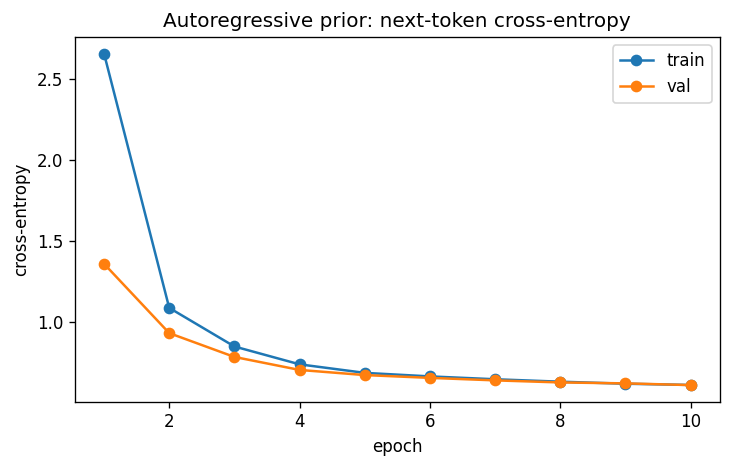

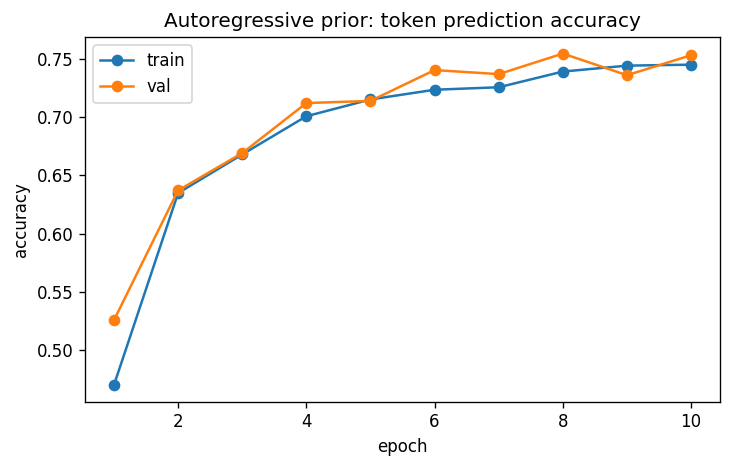

{'latent_grid_shape': (4, 4),
 'sequence_length': 16,
 'unique_codes_seen_in_train': 8,
 'final_val_nll': 0.6085}

In [11]:
train_code_sequences, latent_grid_shape = collect_code_sequences(vqvae_model, train_loader, DEVICE)
val_code_sequences, _ = collect_code_sequences(vqvae_model, val_loader, DEVICE)

prior_model = LatentGRUPrior(
    num_embeddings=CFG["num_embeddings"],
    hidden_dim=CFG["prior_hidden_dim"],
    token_dim=CFG["prior_token_dim"],
).to(DEVICE)

prior_history = train_prior(
    prior=prior_model,
    train_sequences=train_code_sequences,
    val_sequences=val_code_sequences,
    epochs=CFG["prior_epochs"],
    lr=CFG["prior_lr"],
    batch_size=CFG["batch_size"],
    device=DEVICE,
)

plot_history_pair(
    prior_history,
    train_key="train_nll",
    val_key="val_nll",
    title="Autoregressive prior: next-token cross-entropy",
    ylabel="cross-entropy",
)

plot_history_pair(
    prior_history,
    train_key="train_token_accuracy",
    val_key="val_token_accuracy",
    title="Autoregressive prior: token prediction accuracy",
    ylabel="accuracy",
)

{
    "latent_grid_shape": latent_grid_shape,
    "sequence_length": int(train_code_sequences.shape[1]),
    "unique_codes_seen_in_train": int(torch.unique(train_code_sequences).numel()),
    "final_val_nll": round(prior_history[-1]["val_nll"], 4),
}


sampled latent grid shape: (16, 4, 4)


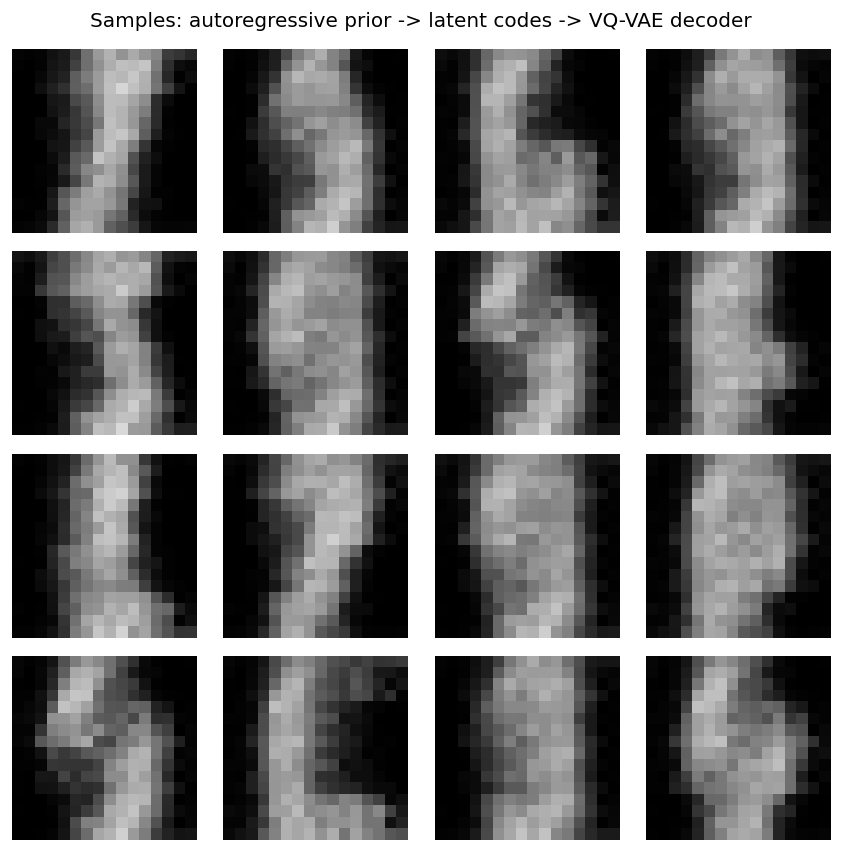

tensor([[[50, 38, 34, 53],
         [50, 38, 34, 50],
         [50, 38, 31, 50],
         [50, 34, 53, 50]],

        [[50, 38, 31, 50],
         [50, 34, 34, 53],
         [50, 38, 34, 53],
         [50, 38, 34, 53]],

        [[38, 34, 53, 50],
         [38, 34, 53, 50],
         [38, 34, 34, 53],
         [38, 34, 34, 53]]], device='mps:0')

In [12]:
with torch.no_grad():
    sampled_sequences = prior_model.sample(
        seq_len=train_code_sequences.shape[1],
        batch_size=16,
        temperature=CFG["sample_temperature"],
        device=DEVICE,
    )
    sampled_grids = sampled_sequences.view(16, *latent_grid_shape)
    sampled_images = vqvae_model.decode_indices(sampled_grids.to(DEVICE)).cpu()

print("sampled latent grid shape:", tuple(sampled_grids.shape))
show_image_grid(
    sampled_images,
    title="Samples: autoregressive prior -> latent codes -> VQ-VAE decoder",
    ncols=4,
)

sampled_grids[:3]


## 9. EMA updates and VQ-VAE-2 in one page

The original VQ-VAE paper updates the codebook with the explicit **codebook loss**.  
A common variant replaces that update with **exponential moving averages (EMA)**:
- keep moving counts of how often codes are used,
- keep moving sums of encoder outputs assigned to each code,
- normalize to obtain updated code vectors.

Why people like EMA updates:
- often more stable in practice,
- less sensitive to noisy minibatch assignments,
- can reduce code collapse.

### VQ-VAE-2

VQ-VAE-2 extends the original tokenizer to a **hierarchy of discrete latent maps**.

A useful mental picture:
- the **top level** captures global structure,
- the **bottom level** captures local detail.

The generative story remains two-stage:
1. learn the hierarchical tokenizer;
2. fit strong autoregressive priors over the discrete codes.

**Seminar line:**  
> "VQ-VAE learns the tokenizer; the prior learns how to speak in those tokens."


## 10. A related alternative: replace hard quantization with Gumbel-Softmax

This section is deliberately framed as a **related discrete-latent variant**, not as the original VQ-VAE objective.

Instead of:
- computing distances to a codebook and taking `argmin`,

we:
- predict **logits over code categories** at each spatial location,
- sample a relaxed one-hot vector with **Gumbel-Softmax**,
- convert that categorical sample into a latent vector by multiplying by the codebook.

The Gumbel-Softmax sample is

$$
y = \operatorname{softmax}\left(\frac{\log \pi + g}{\tau}\right),
$$

where $g$ is i.i.d. Gumbel noise and $\tau$ is the **temperature**.

### Intuition

- high $\tau$  $\rightarrow$  softer assignments,
- low $\tau$   $\rightarrow$  sharper, almost one-hot assignments.

If `hard=True`, PyTorch uses a **straight-through hard sample** in the forward pass while backpropagating through the soft relaxation.

### Main conceptual difference from VQ-VAE

- **VQ-VAE:** hard nearest-neighbor lookup + codebook/commitment losses.
- **Gumbel variant:** differentiable categorical sampling + a regularizer such as KL-to-uniform.

This makes a good second seminar act because students can compare **two different ways to get discrete latent structure**.


In [13]:
class FeatureEncoder(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels // 2, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.ReLU(inplace=False),
            nn.Conv2d(hidden_channels // 2, hidden_channels, kernel_size=4, stride=2, padding=1),  # 8 -> 4
            nn.ReLU(inplace=False),
            ResidualBlock(hidden_channels),
            ResidualBlock(hidden_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class GumbelQuantizer(nn.Module):
    def __init__(self, hidden_channels: int, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim

        self.to_logits = nn.Conv2d(hidden_channels, num_embeddings, kernel_size=1)
        self.codebook = nn.Embedding(num_embeddings, embedding_dim)
        self.codebook.weight.data.uniform_(-1.0 / num_embeddings, 1.0 / num_embeddings)

    def forward(self, h: torch.Tensor, tau: float = 1.0, hard: bool = True):
        logits = self.to_logits(h)  # [B, K, H, W]

        assignments = F.gumbel_softmax(
            logits,
            tau=tau,
            hard=hard,
            dim=1,
        )  # [B, K, H, W]

        z_q = torch.einsum("bkhw,kd->bdhw", assignments, self.codebook.weight)

        probs = logits.softmax(dim=1)
        kl_to_uniform = (
            probs * (torch.log(probs + 1e-10) + math.log(self.num_embeddings))
        ).sum(dim=1).mean()

        hard_indices = assignments.argmax(dim=1)
        usage = F.one_hot(hard_indices.reshape(-1), self.num_embeddings).float().mean(dim=0)
        perplexity = torch.exp(-(usage * torch.log(usage + 1e-10)).sum())

        stats = {
            "logits": logits,
            "assignments": assignments,
            "probs": probs,
            "kl_to_uniform": kl_to_uniform,
            "perplexity": perplexity,
            "indices": hard_indices,
        }
        return z_q, stats


class GumbelVQVAE(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        hidden_channels: int = 64,
        embedding_dim: int = 32,
        num_embeddings: int = 64,
    ):
        super().__init__()
        self.encoder = FeatureEncoder(in_channels, hidden_channels)
        self.quantizer = GumbelQuantizer(hidden_channels, num_embeddings, embedding_dim)
        self.decoder = Decoder(embedding_dim, hidden_channels, in_channels)

    def forward(self, x: torch.Tensor, tau: float = 1.0, hard: bool = True):
        h = self.encoder(x)
        z_q, stats = self.quantizer(h, tau=tau, hard=hard)
        x_recon = self.decoder(z_q)
        return x_recon, stats

    def compute_loss(
        self,
        x: torch.Tensor,
        x_recon: torch.Tensor,
        stats: Dict[str, torch.Tensor],
        kl_weight: float = 5e-4,
    ):
        recon_loss = F.mse_loss(x_recon, x)
        total_loss = recon_loss + kl_weight * stats["kl_to_uniform"]
        return {
            "loss": total_loss,
            "recon_loss": recon_loss,
            **stats,
        }

    @torch.no_grad()
    def encode_to_indices(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x)
        logits = self.quantizer.to_logits(h)
        return logits.argmax(dim=1)

    @torch.no_grad()
    def decode_indices(self, indices: torch.Tensor) -> torch.Tensor:
        z_q = self.quantizer.codebook(indices).permute(0, 3, 1, 2).contiguous()
        return self.decoder(z_q)


def evaluate_gumbel_vqvae(
    model: GumbelVQVAE,
    loader: DataLoader,
    device: torch.device,
    tau: float,
    kl_weight: float,
) -> Dict[str, float]:
    model.eval()
    totals = {"loss": 0.0, "recon_loss": 0.0, "perplexity": 0.0, "kl_to_uniform": 0.0}
    n_examples = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x_recon, stats = model(x, tau=tau, hard=True)
            losses = model.compute_loss(x, x_recon, stats, kl_weight=kl_weight)

            batch_size = x.size(0)
            totals["loss"] += losses["loss"].item() * batch_size
            totals["recon_loss"] += losses["recon_loss"].item() * batch_size
            totals["perplexity"] += losses["perplexity"].item() * batch_size
            totals["kl_to_uniform"] += losses["kl_to_uniform"].item() * batch_size
            n_examples += batch_size

    return {key: value / n_examples for key, value in totals.items()}

def train_gumbel_vqvae(
    model: GumbelVQVAE,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    tau_start: float,
    tau_end: float,
    kl_weight: float,
    device: torch.device,
) -> List[Dict[str, float]]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    tau_schedule = np.geomspace(tau_start, tau_end, num=epochs)
    history = []

    for epoch, tau in enumerate(tau_schedule, start=1):
        model.train()
        totals = {"loss": 0.0, "recon_loss": 0.0, "perplexity": 0.0, "kl_to_uniform": 0.0}
        n_examples = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad(set_to_none=True)
            x_recon, stats = model(x, tau=float(tau), hard=True)
            losses = model.compute_loss(x, x_recon, stats, kl_weight=kl_weight)
            losses["loss"].backward()
            optimizer.step()

            batch_size = x.size(0)
            totals["loss"] += losses["loss"].item() * batch_size
            totals["recon_loss"] += losses["recon_loss"].item() * batch_size
            totals["perplexity"] += losses["perplexity"].item() * batch_size
            totals["kl_to_uniform"] += losses["kl_to_uniform"].item() * batch_size
            n_examples += batch_size

        train_metrics = {key: value / n_examples for key, value in totals.items()}
        val_metrics = evaluate_gumbel_vqvae(
            model=model,
            loader=val_loader,
            device=device,
            tau=float(tau),
            kl_weight=kl_weight,
        )

        row = {
            "epoch": epoch,
            "tau": float(tau),
            "train_loss": train_metrics["loss"],
            "train_recon_loss": train_metrics["recon_loss"],
            "train_perplexity": train_metrics["perplexity"],
            "train_kl_to_uniform": train_metrics["kl_to_uniform"],
            "val_loss": val_metrics["loss"],
            "val_recon_loss": val_metrics["recon_loss"],
            "val_perplexity": val_metrics["perplexity"],
            "val_kl_to_uniform": val_metrics["kl_to_uniform"],
        }
        history.append(row)

        print(
            f"gumbel epoch {epoch:02d}/{epochs} | "
            f"tau={row['tau']:.3f} | "
            f"val loss={row['val_loss']:.4f} | "
            f"val recon={row['val_recon_loss']:.4f} | "
            f"val perplexity={row['val_perplexity']:.2f}"
        )

    return history


In [14]:
set_seed(CFG["seed"])

gumbel_model = GumbelVQVAE(
    in_channels=1,
    hidden_channels=CFG["hidden_channels"],
    embedding_dim=CFG["embedding_dim"],
    num_embeddings=CFG["num_embeddings"],
).to(DEVICE)

gumbel_history = train_gumbel_vqvae(
    model=gumbel_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CFG["gumbel_epochs"],
    lr=CFG["gumbel_lr"],
    tau_start=CFG["gumbel_tau_start"],
    tau_end=CFG["gumbel_tau_end"],
    kl_weight=CFG["gumbel_kl_weight"],
    device=DEVICE,
)

{
    "final_tau": round(gumbel_history[-1]["tau"], 3),
    "final_val_loss": round(gumbel_history[-1]["val_loss"], 4),
    "final_val_recon_loss": round(gumbel_history[-1]["val_recon_loss"], 4),
    "final_val_perplexity": round(gumbel_history[-1]["val_perplexity"], 2),
}


gumbel epoch 01/8 | tau=1.400 | val loss=0.1408 | val recon=0.1387 | val perplexity=1.00
gumbel epoch 02/8 | tau=1.209 | val loss=0.1384 | val recon=0.1363 | val perplexity=1.00
gumbel epoch 03/8 | tau=1.043 | val loss=0.1364 | val recon=0.1343 | val perplexity=1.00
gumbel epoch 04/8 | tau=0.901 | val loss=0.1344 | val recon=0.1323 | val perplexity=1.00
gumbel epoch 05/8 | tau=0.777 | val loss=0.1325 | val recon=0.1304 | val perplexity=1.00
gumbel epoch 06/8 | tau=0.671 | val loss=0.1306 | val recon=0.1285 | val perplexity=1.00
gumbel epoch 07/8 | tau=0.579 | val loss=0.1288 | val recon=0.1267 | val perplexity=1.00
gumbel epoch 08/8 | tau=0.500 | val loss=0.1272 | val recon=0.1251 | val perplexity=1.00


{'final_tau': 0.5,
 'final_val_loss': 0.1272,
 'final_val_recon_loss': 0.1251,
 'final_val_perplexity': 1.0}

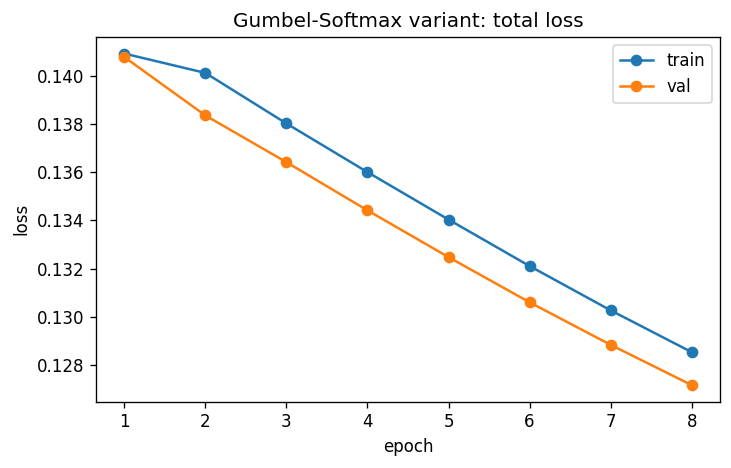

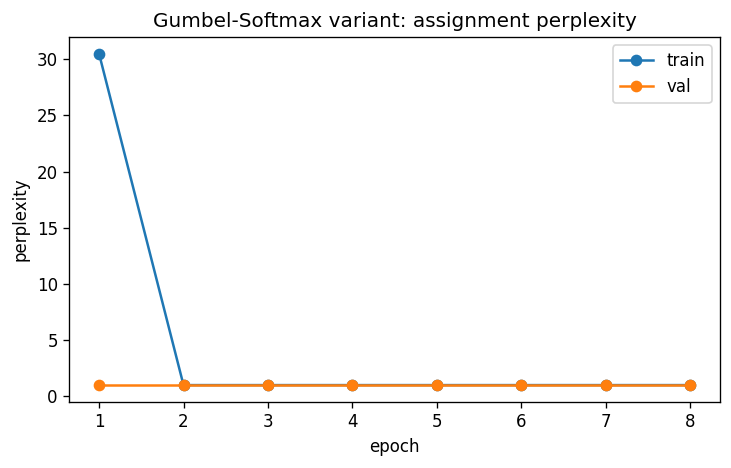

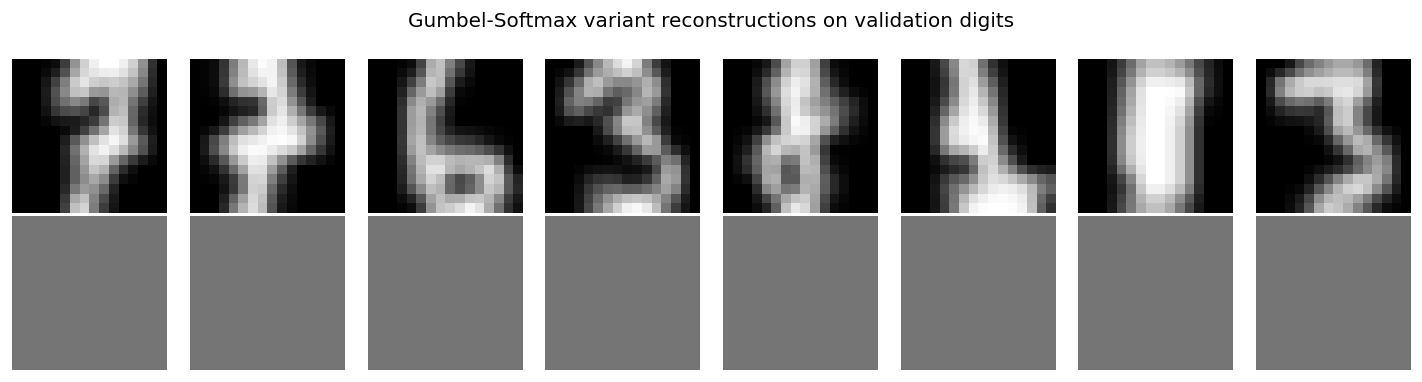

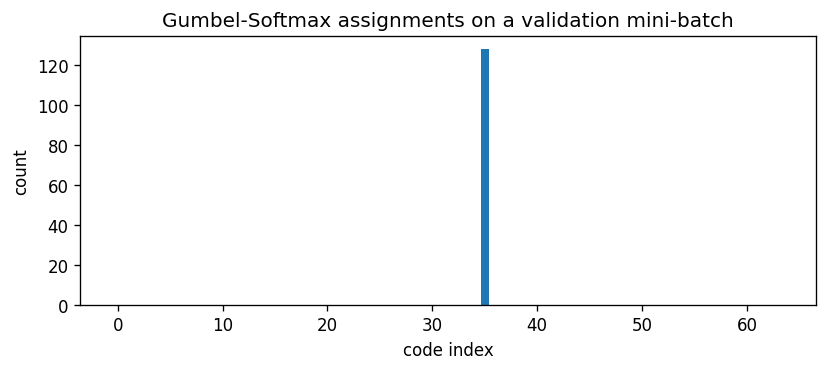

[{'model': 'VQ-VAE',
  'final_val_recon_loss': 0.0278,
  'final_val_perplexity': 4.89,
  'tokenization_rule': 'nearest codebook lookup',
  'regularization': 'codebook + commitment'},
 {'model': 'Gumbel-Softmax variant',
  'final_val_recon_loss': 0.1251,
  'final_val_perplexity': 1.0,
  'tokenization_rule': 'categorical logits + hard/soft samples',
  'regularization': 'KL to uniform'}]

In [15]:
plot_history_pair(
    gumbel_history,
    train_key="train_loss",
    val_key="val_loss",
    title="Gumbel-Softmax variant: total loss",
    ylabel="loss",
)

plot_history_pair(
    gumbel_history,
    train_key="train_perplexity",
    val_key="val_perplexity",
    title="Gumbel-Softmax variant: assignment perplexity",
    ylabel="perplexity",
)

x_val, _ = next(iter(val_loader))
x_val = x_val.to(DEVICE)

with torch.no_grad():
    gumbel_recon, gumbel_stats = gumbel_model(
        x_val[:8],
        tau=CFG["gumbel_tau_end"],
        hard=True,
    )

show_reconstructions(
    x_val[:8],
    gumbel_recon[:8],
    title="Gumbel-Softmax variant reconstructions on validation digits",
    n=8,
)

code_usage_histogram(
    gumbel_stats["indices"],
    num_embeddings=CFG["num_embeddings"],
    title="Gumbel-Softmax assignments on a validation mini-batch",
)

comparison = [
    {
        "model": "VQ-VAE",
        "final_val_recon_loss": round(vq_history[-1]["val_recon_loss"], 4),
        "final_val_perplexity": round(vq_history[-1]["val_perplexity"], 2),
        "tokenization_rule": "nearest codebook lookup",
        "regularization": "codebook + commitment",
    },
    {
        "model": "Gumbel-Softmax variant",
        "final_val_recon_loss": round(gumbel_history[-1]["val_recon_loss"], 4),
        "final_val_perplexity": round(gumbel_history[-1]["val_perplexity"], 2),
        "tokenization_rule": "categorical logits + hard/soft samples",
        "regularization": "KL to uniform",
    },
]
comparison


## 11. Side-by-side comparison for the seminar

| Aspect | Original VQ-VAE | Gumbel-Softmax variant |
|---|---|---|
| Discrete choice | nearest codebook vector via `argmin` | relaxed categorical sample from logits |
| Gradient trick | straight-through through hard quantization | reparameterized Gumbel-Softmax; optionally hard straight-through |
| Extra terms | codebook loss + commitment loss | usually KL / entropy regularization |
| Codebook update path | selected embeddings move toward encoder outputs | codebook is updated through weighted categorical mixtures |
| Best classroom use | explain the original paper | contrast a differentiable alternative |

### Practical interpretation

- VQ-VAE gives a very clean **tokenizer + prior** story.
- Gumbel-Softmax gives a very clean **discrete latent reparameterization** story.
- Putting them side by side helps students separate the ideas:
  - discrete latent variables,
  - straight-through estimators,
  - codebooks,
  - and autoregressive priors.


## 12. Common failure modes and diagnostics

### Dead codes in VQ-VAE
Symptoms:
- low perplexity,
- many rarely used code indices.

Possible fixes:
- reduce codebook size,
- use EMA updates,
- reinitialize dead codes,
- train longer or use more diverse data.

### Overly sharp or overly soft Gumbel assignments
Symptoms:
- if temperature is too low too early, optimization can become unstable;
- if temperature stays too high, assignments remain diffuse and the latent bottleneck is weak.

Possible fixes:
- anneal the temperature more slowly,
- use a stronger KL or entropy regularizer only after reconstructions start improving,
- inspect assignment perplexity during training.

### Prior mismatch
Symptoms:
- reconstructions are good, but sampled images are weak.

Interpretation:
- the tokenizer learned useful codes,
- but the autoregressive prior has not yet learned the code distribution well enough.

**Teaching cue:** ask  
> "Which part is failing here: the compressor, the decoder, or the language model over codes?"


## 13. High-yield seminar questions

1. Why might discrete latents be more natural than continuous ones for speech, language, or symbolic structure?
2. Why is nearest-neighbor lookup non-differentiable?
3. What exactly does the straight-through estimator approximate?
4. Why can tokenizer learning and prior learning be separated in the original VQ-VAE story?
5. What does codebook perplexity tell us?
6. Why might a hierarchical latent space help large images?
7. In the Gumbel-Softmax variant, what role does the temperature $\tau$ play?
8. Which model component learns the **alphabet**, and which one learns the **grammar** of the code sequence?


## 14. Suggested exercises for students

### Exercise 1
Replace the explicit codebook loss with an EMA update and compare code usage.

### Exercise 2
Change the codebook size $K$ and compare:
- reconstruction quality,
- perplexity,
- number of effectively used codes.

### Exercise 3
Replace the GRU prior with a masked-convolution prior or a tiny Transformer over latent indices.

### Exercise 4
Compare the original VQ-VAE bottleneck with the Gumbel-Softmax variant:
- which trains more smoothly?
- which gives crisper discrete behavior?
- which uses the code space more uniformly?

### Exercise 5
Swap the digits demo dataset for MNIST, Fashion-MNIST, or image patches and repeat the same seminar pipeline.


## 15. Three takeaways to end the seminar

1. **VQ-VAE turns latent representations into discrete tokens** by nearest-neighbor lookup in a learned codebook.
2. **Generation is naturally split into two stages:** learn the tokenizer, then learn a prior over the discrete indices.
3. **Gumbel-Softmax offers a related route to discrete latents** by replacing hard lookup with a differentiable categorical relaxation.

## References

**Primary papers**
1. Aaron van den Oord, Oriol Vinyals, Koray Kavukcuoglu. *Neural Discrete Representation Learning*. NeurIPS 2017. `arXiv:1711.00937`
2. Ali Razavi, Aaron van den Oord, Oriol Vinyals. *Generating Diverse High-Fidelity Images with VQ-VAE-2*. NeurIPS 2019. `arXiv:1906.00446`
3. Eric Jang, Shixiang Gu, Ben Poole. *Categorical Reparameterization with Gumbel-Softmax*. ICLR 2017. `arXiv:1611.01144`
4. Chris J. Maddison, Andriy Mnih, Yee Whye Teh. *The Concrete Distribution: A Continuous Relaxation of Discrete Random Variables*. ICLR 2017. `arXiv:1611.00712`

**What to emphasize in Q&A**
- VQ-VAE is about **latent quantization**, not quantizing model weights.
- The code index is the discrete token.
- The prior lives in **compressed latent space**, not directly in pixels.
- The Gumbel-Softmax section is a **related alternative**, not the original VQ-VAE loss.
